# Fake News Analysis
Is notebook mein hum `dataset.csv` (News_Text, Label) par ek text-based Fake News Detection model banayenge.

**Workflow:**
1. Data Load + EDA
2. Text Preprocessing (Cleaning)
3. Label Encoding (Target)
4. Train-Test Split
5. TF-IDF Vectorization
6. Multiple Models Train karna (Logistic Regression, Naive Bayes, Random Forest, SVM)
7. Best Model Select karna
8. Sample Prediction (naya news text dekar Fake/Real predict karna)


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")


## 1. Load Data & Explore

In [2]:
# ── Load Data ──────────────────────────────────────────────────────────────
df = pd.read_csv('dataset.csv')

print("Shape     :", df.shape)
print("Columns   :", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

print("\nInfo:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Shape     : (600, 2)
Columns   : ['News_Text', 'Label']

First 5 rows:
                                           News_Text Label
0  According to sources, The city council approve...  Real
1  Update: Local authorities confirmed water supp...  Real
2  Update: Billionaire secretly funding time trav...  Fake
3  BREAKING: Local police arrested three suspects...  Real
4  Politician caught on secret tape admitting to ...  Fake

Info:
<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   News_Text  600 non-null    str  
 1   Label      600 non-null    str  
dtypes: str(2)
memory usage: 9.5 KB

Missing values:
News_Text    0
Label        0
dtype: int64

Duplicate rows: 80


## 2. Exploratory Data Analysis (EDA)

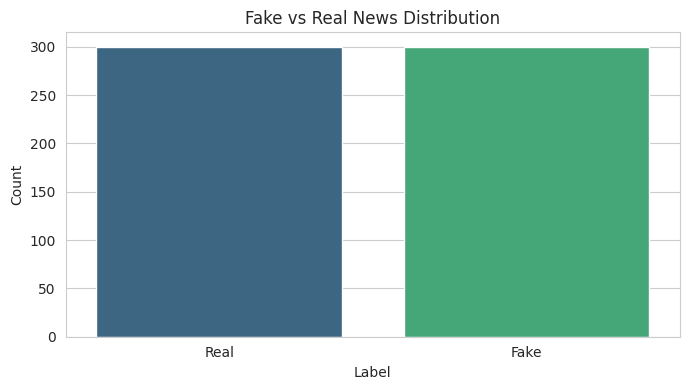

In [3]:
# ── EDA Plot 1: Label Distribution ──────────────────────────────────────────
plt.figure(figsize=(7,4))
sns.countplot(x='Label', data=df, order=df['Label'].value_counts().index, palette='viridis')
plt.title("Fake vs Real News Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("label_distribution.png", dpi=120)
plt.show()


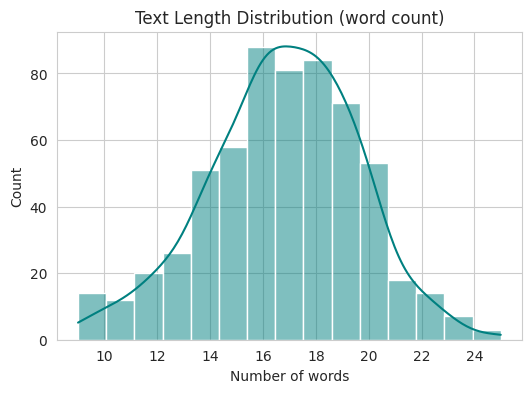

In [4]:
# ── EDA Plot 2: Text Length Distribution ────────────────────────────────────
df['text_length'] = df['News_Text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(6,4))
sns.histplot(df['text_length'], kde=True, bins=15, color='teal')
plt.title("Text Length Distribution (word count)")
plt.xlabel("Number of words")
plt.show()


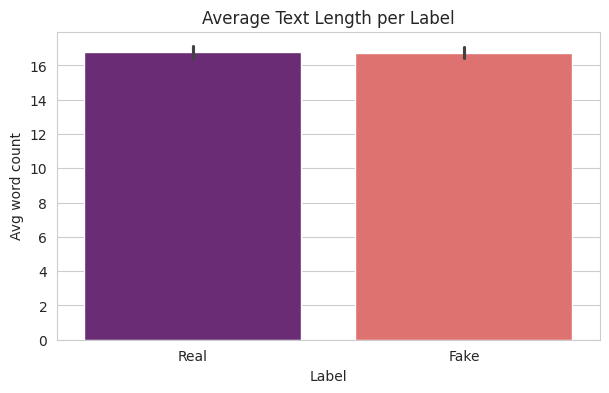

In [5]:
# ── EDA Plot 3: Avg text length per label ───────────────────────────────────
plt.figure(figsize=(7,4))
sns.barplot(x='Label', y='text_length', data=df, estimator=np.mean, palette='magma')
plt.title("Average Text Length per Label")
plt.ylabel("Avg word count")
plt.show()


In [6]:
# ── Unique news items per label (sanity check) ──────────────────────────────
print(df.groupby('Label')['News_Text'].nunique())


Label
Fake    259
Real    261
Name: News_Text, dtype: int64


## 3. Text Preprocessing
Text ko clean karte hain: lowercase, punctuation remove, extra spaces remove.


In [7]:
# ── Text Cleaning Function ──────────────────────────────────────────────────
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)   # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text

df['Clean_Text'] = df['News_Text'].apply(clean_text)
df[['News_Text', 'Clean_Text']].head(10)


,News_Text,Clean_Text
0,"According to sources, The city council approve...",according to sources the city council approved...
1,Update: Local authorities confirmed water supp...,update local authorities confirmed water suppl...
2,Update: Billionaire secretly funding time trav...,update billionaire secretly funding time trave...
3,BREAKING: Local police arrested three suspects...,breaking local police arrested three suspects ...
4,Politician caught on secret tape admitting to ...,politician caught on secret tape admitting to ...
5,Reports say Shocking! Scientists secretly conf...,reports say shocking scientists secretly confi...
6,"In a recent update, Researchers published a pe...",in a recent update researchers published a pee...
7,"According to sources, Scientists confirm moon ...",according to sources scientists confirm moon l...
8,Scientists at ISRO successfully launched a new...,scientists at isro successfully launched a new...
9,5G towers are secretly causing mass mind contr...,g towers are secretly causing mass mind contro...


## 4. Label Encoding (Target Column)

In [8]:
# ── Encode Label (Fake/Real) into numbers ───────────────────────────────────
encoder = LabelEncoder()
df['Label_Encoded'] = encoder.fit_transform(df['Label'])

label_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print("Label Mapping:", label_mapping)


Label Mapping: {'Fake': np.int64(0), 'Real': np.int64(1)}


## 5. Features and Target

In [9]:
# Features and Target
X_text = df['Clean_Text']
y = df['Label_Encoded']


## 6. Train-Test Split

In [10]:
# ── Train-Test Split ─────────────────────────────────────────────────────────
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train_text.shape[0])
print("Test size :", X_test_text.shape[0])


Train size: 480
Test size : 120


## 7. TF-IDF Vectorization
Text ko numeric features mein convert karte hain taaki ML models train ho sakein.


In [11]:
# ── TF-IDF Vectorization ─────────────────────────────────────────────────────
tfidf = TfidfVectorizer(max_features=500, ngram_range=(1,2))

X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print("TF-IDF feature matrix shape (train):", X_train.shape)
print("TF-IDF feature matrix shape (test) :", X_test.shape)


TF-IDF feature matrix shape (train): (480, 500)
TF-IDF feature matrix shape (test) : (120, 500)


## 8. Train Multiple Models

In [12]:
# ------------------ Train Multiple Models ------------------

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Linear SVM": LinearSVC(random_state=42)
}

results = []

print("Model Performance\n")

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append((name, acc, f1))

    print(f"{name:25s} -> Accuracy: {acc:.4f} | F1 Score: {f1:.4f}")


Model Performance

Logistic Regression       -> Accuracy: 1.0000 | F1 Score: 1.0000
Multinomial Naive Bayes   -> Accuracy: 1.0000 | F1 Score: 1.0000


Random Forest             -> Accuracy: 1.0000 | F1 Score: 1.0000
Linear SVM                -> Accuracy: 1.0000 | F1 Score: 1.0000


## 9. Compare Models

In [13]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1 Score"])
print(results_df)


                     Model  Accuracy  F1 Score
0      Logistic Regression       1.0       1.0
1  Multinomial Naive Bayes       1.0       1.0
2            Random Forest       1.0       1.0
3               Linear SVM       1.0       1.0


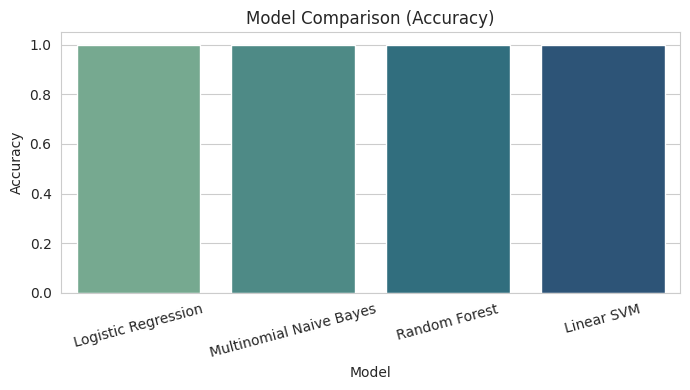

In [14]:
plt.figure(figsize=(7,4))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='crest')
plt.title("Model Comparison (Accuracy)")
plt.xticks(rotation=15)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


## 10. Select the Best Model

In [15]:
#Select the Best Model
best_model_row = results_df.loc[results_df["F1 Score"].idxmax()]

print("Best Model")
print(best_model_row)

best = models[best_model_row["Model"]]


Best Model
Model       Logistic Regression
Accuracy                    1.0
F1 Score                    1.0
Name: 0, dtype: object


## 11. Detailed Evaluation of Best Model

Classification Report:

              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00        60
        Real       1.00      1.00      1.00        60

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



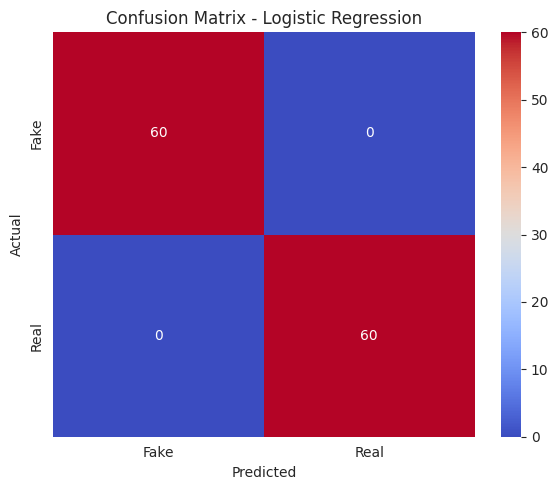

In [16]:
y_pred_best = best.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred_best, target_names=encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="coolwarm",
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title(f"Confusion Matrix - {best_model_row['Model']}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


## 12. Use the Best Model for Prediction
Naya news text dekar uska Fake/Real label predict karte hain.


In [17]:
def predict_news(text):
    cleaned = clean_text(text)
    vec = tfidf.transform([cleaned])
    pred_label = best.predict(vec)[0]
    pred_class = encoder.inverse_transform([pred_label])[0]
    return pred_class

# ── Sample Predictions ───────────────────────────────────────────────────────
samples = [
    "The Reserve Bank of India kept the repo rate unchanged at its latest policy meeting.",
    "Shocking! Scientists secretly confirm the earth will stop spinning next week.",
    "The government announced a new infrastructure budget for rural roads.",
    "Miracle fruit melts fat overnight, doctors hate this one simple trick.",
    "Local authorities confirmed water supply will resume by evening after the pipeline repair."
]

for text in samples:
    print(f"Text: {text}")
    print(f"Predicted Label: {predict_news(text)}")
    print("-" * 60)


Text: The Reserve Bank of India kept the repo rate unchanged at its latest policy meeting.
Predicted Label: Real
------------------------------------------------------------
Text: Shocking! Scientists secretly confirm the earth will stop spinning next week.
Predicted Label: Fake
------------------------------------------------------------
Text: The government announced a new infrastructure budget for rural roads.
Predicted Label: Real
------------------------------------------------------------
Text: Miracle fruit melts fat overnight, doctors hate this one simple trick.
Predicted Label: Fake
------------------------------------------------------------
Text: Local authorities confirmed water supply will resume by evening after the pipeline repair.
Predicted Label: Real
------------------------------------------------------------
